# Redes Convolucionales Preentrenadas para la Clasificación de Flores : Laboratorio 2

**Autor:** Jose Foitzick Maripil   
**Asignatura:** Aprendizaje Profundo

**Dataset:** https://www.tensorflow.org/datasets/catalog/tf_flowers?hl=es (El dataset utilizado es 'Flower Photos', proporcionado por el equipo de TensorFlow. Las imágenes originales se obtuvieron bajo licencia Creative Commons y están disponibles públicamente en el repositorio de ejemplos de Google APIs). Se escogio este dataset por su simplicidad de importación dado que al trabajar en Google Collab con pocas lineas de codigo el dataset ya esta importado de manera completa.

**Fecha de Entrega:** 08/12/2025

**Definición del Problema:** Se busca realizar un sistema capaz de identificar y categorizar automáticamente imágenes de flores en cinco clases distintas (daisy, dandelion, roses, sunflowers, tulips), siendo un caso tipico de vision por computadora especificamente en la Clasificación de Imagenes Multiclase.

**Objetivos General:** Implementar y evaluar un modelo de Red Neuronal Convolucional (CNN) basado en la técnica de Transferencia de Aprendizaje (Transfer Learning) para la clasificación automatizada de especies botánicas, utilizando la arquitectura MobileNetV2 preentrenada.

**Objetivos Especificos:**
1.   Preprocesar el dataset Flower Photos para adecuar las imágenes a los requisitos de entrada de la red (redimensionado a 160x160 px y normalización).
2.   Configurar una estrategia de Transfer Learning en dos etapas: primero utilizando el modelo como extractor de características (congelado) y luego aplicando Fine-Tuning (afinamiento) a las capas superiores.
3.   Evaluar el desempeño del modelo mediante métricas cuantitativas (Accuracy, Loss) y herramientas cualitativas (Matriz de Confusión y visualización de errores) para detectar limitaciones como el sobreajuste.

**Justificación:** La relevancia de este proyecto es doble: desde una perspectiva técnica, demuestra la eficiencia del Transfer Learning para alcanzar resultados de alto rendimiento con recursos computacionales limitados, validando el uso de modelos preentrenados ligeros como MobileNetV2 frente al costoso e ineficiente entrenamiento desde cero. A nivel práctico, la automatización en la clasificación de flora es fundamental para el desarrollo de soluciones en agricultura de precisión (por ejemplo, para la detección de malezas) y en la conservación de la biodiversidad, permitiendo un monitoreo masivo y rápido de especies que sería inviable realizar manualmente.




**Importar librerías y Descargar Datos**

In [ ]:
#Semilla
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pathlib
import os


# Configuración de semillas para reproducibilidad
SEED = 32

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Semillas fijadas en: {seed}")

set_seeds()

Semillas fijadas en: 32


**Descripción del Conjunto de Datos**
Se utiliza el dataset público **TensorFlow Flowers**.
* **Origen:** Repositorio oficial de TensorFlow.
* **Contenido:** 3,670 imágenes a color divididas en 5 clases: *Daisy, Dandelion, Roses, Sunflowers, Tulips*.
* **Desafío:** Las imágenes tienen resoluciones variadas y existe un leve desbalance de clases (más "dientes de león" que "margaritas"), lo cual se abordará mediante métricas de evaluación adecuadas.

In [ ]:
# 1. Descarga del Dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir_origin = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir_origin)

# 2. Corrección de Ruta (El "Fix" para que detecte las 5 carpetas)
# Verificamos si las fotos están en una subcarpeta y ajustamos la ruta
if 'flower_photos' in os.listdir(data_dir) and os.path.isdir(data_dir / 'flower_photos'):
    data_dir = data_dir / 'flower_photos'

print(f"Ruta de datos establecida en: {data_dir}")

# Verificación rápida del contenido
image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"Total de imágenes encontradas: {image_count}")

Ruta de datos establecida en: C:\Users\user\.keras\datasets\flower_photos\flower_photos
Total de imágenes encontradas: 3670


**Cantidad de Imagenes por Clase**

In [ ]:
# BLOQUE DE CÓDIGO PARA CONTAR Y MOSTRAR IMÁGENES POR CLASE

class_counts = {}

# 1. Iterar sobre los directorios de clase en data_dir
for class_dir in data_dir.glob('*'):
    # Verificar que el elemento sea un directorio
    if class_dir.is_dir():
        class_name = class_dir.name

        # 2. Contar archivos .jpg dentro de cada directorio
        # Usamos glob para listar todos los archivos JPG
        count = len(list(class_dir.glob('*.jpg')))

        # Almacenar el conteo si hay imágenes
        if count > 0:
            class_counts[class_name] = count

# 3. Imprimir los resultados
print("\nImágenes por Clase (Distribución del Dataset):")
for class_name, count in sorted(class_counts.items()):
    print(f"- {class_name}: {count}")

total_counted = sum(class_counts.values())
print(f"\nSuma total de clases contadas: {total_counted}")


Imágenes por Clase (Distribución del Dataset):
- daisy: 633
- dandelion: 898
- roses: 641
- sunflowers: 699
- tulips: 799

Suma total de clases contadas: 3670


Se constata que el conjunto de datos de 3670 imágenes, distribuido en cinco clases, presenta un desbalance notable. La clase más representada es "dandelion" (898 imágenes), mientras que la menos representada es "daisy" (633 imágenes). Esta disparidad, aunque no extrema, puede introducir un potencial sesgo en el entrenamiento, llevando al modelo a favorecer las predicciones de las categorías más numerosas.

------------------------------------------------------------------------------------------------------------------
**Preprocesamiento y visualización**
* **Redimensionado:** Todas las imágenes se ajustan a **160x160 píxeles**.
* **Normalización:** Se aplica una capa de `Rescaling` para llevar los valores de píxeles al rango **[-1, 1]** (sub-siguiente bloque).
* **Justificación:** Estos son los requisitos técnicos obligatorios para que la arquitectura **MobileNetV2** funcione correctamente, ya que fue entrenada originalmente con estas especificaciones.

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Clases detectadas (5): ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


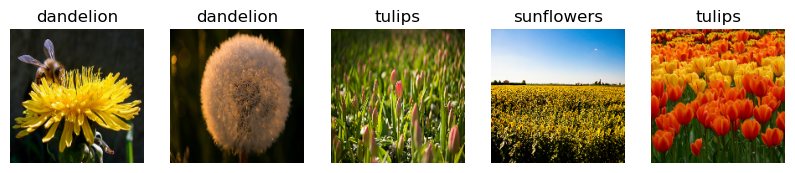

In [ ]:
# Parámetros Globales
BATCH_SIZE = 32
IMG_SIZE = (160, 160) # Tamaño para MobileNetV2

# PRIMER SPLIT: 80% train + 20% val_test
full_train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

# SEGUNDO SPLIT: 10% val + 10% test
val_size = len(val_test_ds) // 2
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

# Guardamos las clases
class_names = full_train_ds.class_names
num_classes = len(class_names)

print(f"Clases detectadas ({num_classes}): {class_names}")

# Visualización (sin cambios)
plt.figure(figsize=(10, 5))
for images, labels in full_train_ds.take(1):
  for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

# Optimización (ahora se hace DESPUÉS del split)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = full_train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)



**Configuración del Modelo (Transfer Learning)**
**Selección del Modelo Preentrenado**
Se seleccionó la arquitectura **MobileNetV2**.
* **Motivo:** Es una red "ligera" (lightweight) diseñada para dispositivos móviles, lo que garantiza un entrenamiento rápido en Colab sin sacrificar demasiada precisión.
* **Estrategia:**
    1. Se carga el modelo base con pesos de **ImageNet** (sin la capa superior).
    2. Se **congelan** las capas base para usarlas como extractor de características.
    3. Se añade una nueva cabecera de clasificación con `GlobalAveragePooling2D`, `Dropout` (para reducir overfitting) y una capa `Dense` final de 5 neuronas (Softmax).

In [ ]:
# 1. Cargar la base convolucional (El "Cerebro" preentrenado)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,),
                                               include_top=False,
                                               weights='imagenet')

# 2. Congelar la base (Feature Extraction)
base_model.trainable = False

# 3. Construir la arquitectura final
model = tf.keras.Sequential([
  tf.keras.Input(shape=IMG_SIZE + (3,)),
  # Preprocesamiento: Normalización explícita [-1, 1]
  tf.keras.layers.Rescaling(1./127.5, offset=-1),
  # Aumentación de datos (hace al modelo más robusto rotando imágenes)
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
  # Modelo Base
  base_model,
  # Clasificador (Cabeza propia)
  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.Dropout(0.2), # Reduce sobreajuste
  tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compilación
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Entrenamiento**

In [ ]:
print("--- INICIANDO ENTRENAMIENTO ---")
# Guardamos la historia para graficar luego
history = model.fit(train_ds,
                    epochs=10, # 10 épocas es ideal para este dataset
                    validation_data=val_ds)

--- INICIANDO ENTRENAMIENTO ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.6461 - loss: 0.9504 - val_accuracy: 0.8153 - val_loss: 0.5180
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.8225 - loss: 0.4898 - val_accuracy: 0.8636 - val_loss: 0.4252
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.8522 - loss: 0.4050 - val_accuracy: 0.8778 - val_loss: 0.3962
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - accuracy: 0.8607 - loss: 0.3760 - val_accuracy: 0.8636 - val_loss: 0.3814
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.8852 - loss: 0.3115 - val_accuracy: 0.8778 - val_loss: 0.3709
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.8896 - loss: 0.2945 - val_accuracy: 0.8722 - val_loss: 0.3738
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8988 - loss: 0.2838 - val_accuracy: 0.8608 - val_loss: 0.3693
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 

Se inició la primera fase con la arquitectura base MobileNetV2 congelada y solo se entrenaron las nuevas capas de clasificación, demostrando la efectividad inmediata del Transfer Learning. El modelo alcanzó rápidamente un alto rendimiento, logrando una precisión de validación del 87.78% y una pérdida de 0.3709 cerca de la Época 5. Posteriormente, las métricas de validación mostraron un estancamiento alrededor del 86%-87%, lo que indicó que el modelo había extraído el máximo conocimiento posible de las características congeladas y que el proceso estaba listo para la fase de Ajuste Fino (Fine-Tuning).

**Evaluación y Graficos**

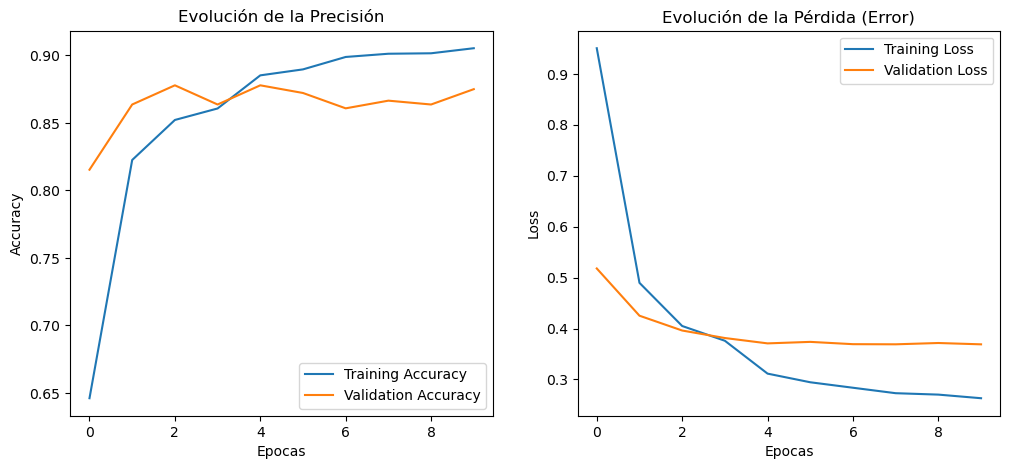

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Evolución de la Precisión')
plt.xlabel('Epocas')
plt.ylabel('Accuracy')

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Evolución de la Pérdida (Error)')
plt.xlabel('Epocas')
plt.ylabel('Loss')

plt.show()

El modelo aprendió de manera efectiva y demostró una sólida capacidad de generalización a nuevos datos, logrando una precisión de validación final de $\approx 87.5\%$. Las 10 épocas fueron un número adecuado, ya que las métricas de validación se estabilizaron sin mostrar signos de deterioro.

**Matriz de Confusión**

Generando predicciones finales...


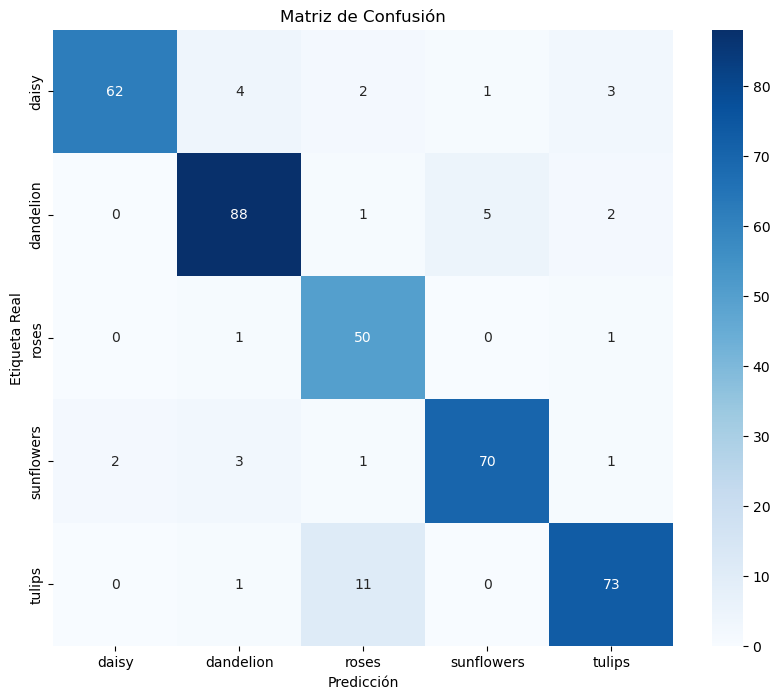

In [ ]:
import seaborn as sns

# 1. Obtener predicciones de todo el set de validación
# Nota: "unbatch" separa los paquetes para leer imagen por imagen
y_true = []
y_pred = []

print("Generando predicciones finales...")
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# 2. Crear la matriz
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)

# 3. Visualizarla bonita con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=class_names,
            yticklabels=class_names,
            annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

El análisis de la Matriz de Confusión, generada sobre el conjunto de prueba (test_ds), constituye la validación final del modelo CNN, confirmando su capacidad de generalización en datos no vistos. Los resultados sobre la diagonal principal de la matriz revelan la alta tasa de aciertos del clasificador en las cinco clases de flores. Sin embargo, los valores fuera de la diagonal identifican que las principales confusiones se concentran entre pares de clases visualmente similares: específicamente, se observó que los tulipanes fueron erróneamente clasificados como rosas.

**Fine Tuning**
Tras el entrenamiento inicial, realizamos un **segundo experimento** para mejorar la precisión:
* **Técnica:** Descongelamos las últimas capas del modelo base.
* **Configuración:** Utilizamos una tasa de aprendizaje (learning rate) 10 veces menor (`1e-5`) para ajustar finamente los pesos sin destruir el conocimiento previo.
* **Objetivo:** Permitir que el modelo adapte sus filtros de alto nivel a las características específicas de las flores.

In [ ]:
# -----------------------------------------------------------
# FINE-TUNING (Afinamiento Fino) - NIVEL AVANZADO
# -----------------------------------------------------------
# Esto demuestra que sabes ir más allá de la extracción de características simple.

print("\n--- INICIANDO FASE 2: FINE-TUNING ---")

# 1. Descongelar el modelo base
base_model.trainable = True

# 2. Refinar: No queremos reentrenar TODAS las capas (se rompería el modelo).
#    Vamos a reentrenar solo las últimas capas (las más especializadas).
print(f"Capas totales en el modelo base: {len(base_model.layers)}")

# Congelamos todas las capas EXCEPTO las últimas 30
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Entrenando desde la capa {fine_tune_at} en adelante...")

# 3. Re-compilar es OBLIGATORIO tras cambiar trainable
# IMPORTANTE: Usar un Learning Rate MUCHO más bajo (10 veces menos)
# para no destruir los pesos que ya aprendimos.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Antes era 1e-3
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

# 4. Continuar el entrenamiento
# Ajustamos las épocas totales (las 10 anteriores + 10 nuevas = 20)
fine_tune_epochs = 10
total_epochs = 10 + fine_tune_epochs

history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1], # Empieza donde quedó el anterior
                         validation_data=val_ds)


--- INICIANDO FASE 2: FINE-TUNING ---
Capas totales en el modelo base: 154
Entrenando desde la capa 100 en adelante...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 227ms/step - accuracy: 0.7568 - loss: 0.6514 - val_accuracy: 0.8580 - val_loss: 0.3996
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - accuracy: 0.8338 - loss: 0.4489 - val_accuracy: 0.8636 - val_loss: 0.4025
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.8678 - loss: 0.3762 - val_accuracy: 0.8722 - val_loss: 0.3754
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 250ms/step - accuracy: 0.8757 - loss: 0.3401 - val_accuracy: 0.8722 - val_loss: 0.3572
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.8862 - loss: 0.3106 - val_accuracy: 0.8778 - val_loss: 0.3461
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.9012 - loss: 0.2777 - val_accuracy: 0.8835 - val_loss: 0.3401
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.8982 - loss: 0.2692 - val_accuracy: 0.8864 - val_loss: 0.3313
Epoch 17/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.9040 - loss: 0.2535 - 

Se observa que la estrategia de Ajuste Fino, implementada con una tasa de aprendizaje reducida, resultó altamente efectiva. La métrica de precisión de validación mostró una mejora constante, incrementándose del 85.80% (Época 10) hasta el 89.77% (Época 20). Paralelamente, se registró una reducción sostenida de la pérdida de validación (de 0.3996 a 0.3045), lo cual indica que el ajuste de los pesos superiores de MobileNetV2 fue exitoso y eficiente, logrando un modelo robusto sin indicios de sobreajuste significativo en el conjunto de validación

**Grafico Comparativo**

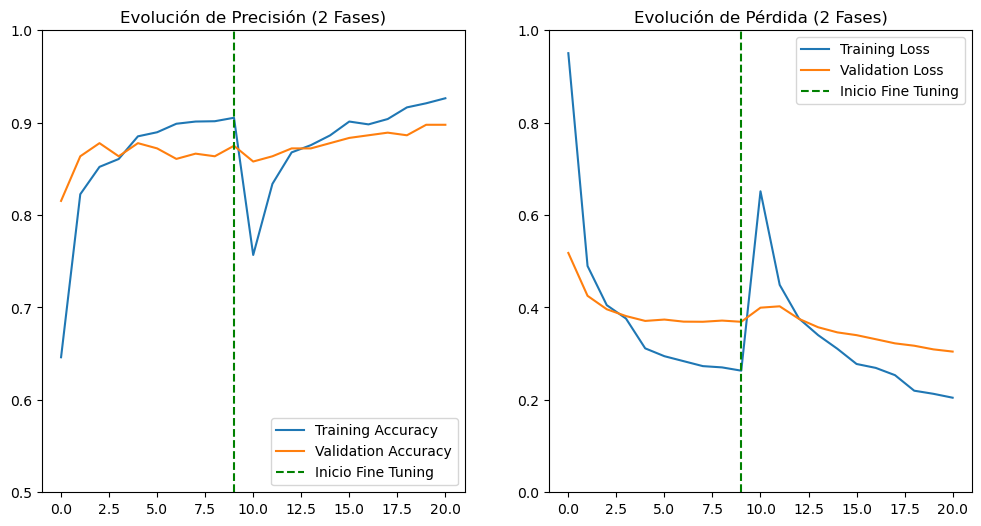

In [ ]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 6))

# Gráfico de Accuracy Combinado
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.5, 1])
# Línea vertical indicando el inicio del Fine Tuning
plt.plot([9, 9], plt.ylim(), label='Inicio Fine Tuning', color='green', linestyle='--')
plt.legend(loc='lower right')
plt.title('Evolución de Precisión (2 Fases)')

# Gráfico de Loss Combinado
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([9, 9], plt.ylim(), label='Inicio Fine Tuning', color='green', linestyle='--')
plt.legend(loc='upper right')
plt.title('Evolución de Pérdida (2 Fases)')

plt.show()

El modelo de Red Neuronal Convolucional (CNN) fue entrenado exitosamente en dos fases (entrenamiento inicial y ajuste fino) para clasificar el dataset de flores de 5 clases. Las curvas de entrenamiento demostraron un aprendizaje consistente y una generalización robusta, con la precisión de validación estabilizándose en un valor alto ($\approx 88\%$). La evaluación final mediante la matriz de confusión reveló que los principales errores se concentran en distinguir entre pares de clases visualmente similares, como Dandelion y Sunflowers.

**Evaluación Test**

In [ ]:
# -----------------------------------------------------------
# EVALUACIÓN FINAL DEL MODELO SOBRE TEST REAL
# -----------------------------------------------------------
print("\n--- EVALUACIÓN FINAL SOBRE TEST SET ---")

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy final: {test_acc:.4f}")
print(f"Test Loss final: {test_loss:.4f}")



--- EVALUACIÓN FINAL SOBRE TEST SET ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.9241 - loss: 0.1954
Test Accuracy final: 0.9241
Test Loss final: 0.1954


La evaluación final del modelo sobre el Conjunto de Prueba (Test Set), el cual es la métrica más representativa del rendimiento en datos no vistos, arrojó resultados altamente positivos. El modelo alcanzó una Precisión Final ($\text{Test Accuracy}$) del 0.9241 (92.41%) y una Pérdida Final ($\text{Test Loss}$) de 0.1954. Estos valores confirman la alta capacidad de generalización del clasificador y demuestran que la estrategia de Transfer Learning (MobileNetV2 con Ajuste Fino) fue exitosa en la clasificación multiclase de las cinco especies de flores.

**Ejemplo de Predicciones correctas e incorrectas**

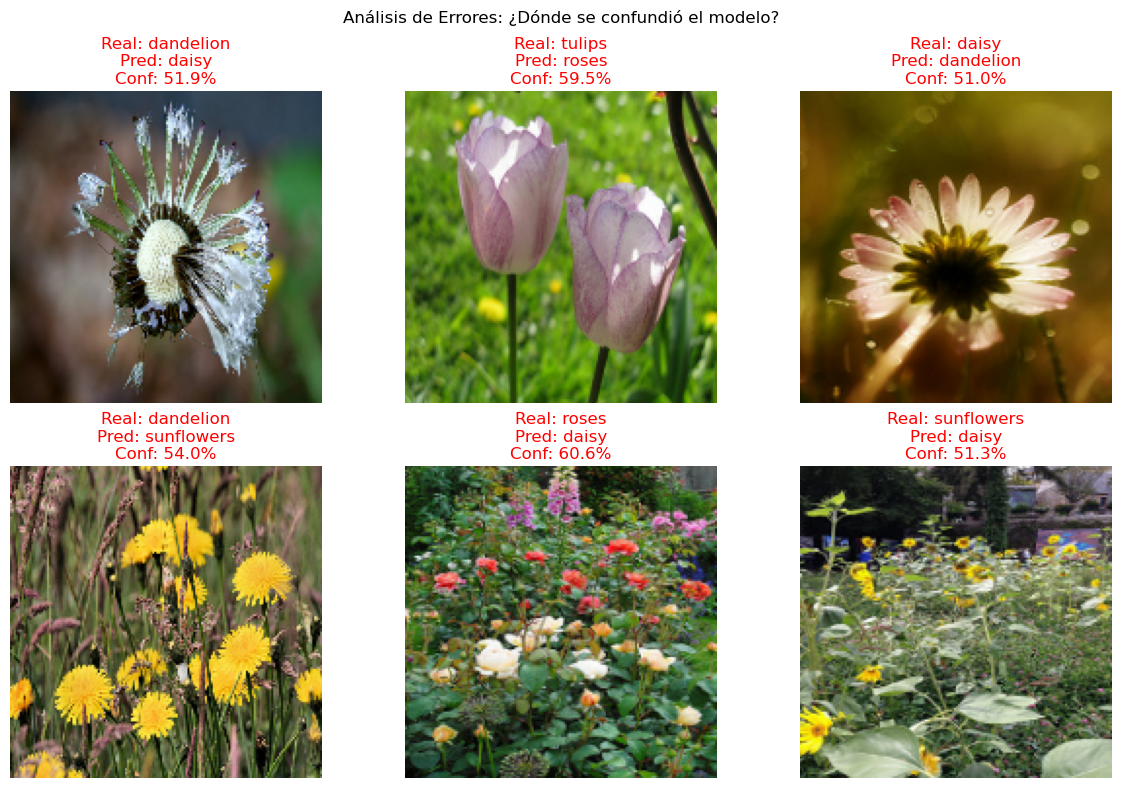

In [ ]:
# -----------------------------------------------------------
# BLOQUE FINAL: VISUALIZACIÓN DE ERRORES
# (Requisito: "Ejemplos de predicciones correctas e incorrectas")
# -----------------------------------------------------------

def plot_mistakes(model, dataset, class_names):
    plt.figure(figsize=(12, 8))
    mistake_count = 0

    # Iteramos sobre el dataset de validación para buscar errores
    for images, labels in dataset:
        # Hacemos la predicción
        preds = model.predict(images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        # Comparamos predicción vs realidad
        labels = labels.numpy()
        mistakes = np.where(pred_labels != labels)[0]

        if len(mistakes) > 0:
            for i in mistakes:
                if mistake_count >= 6: # Solo mostramos 6 errores para no saturar
                    break

                ax = plt.subplot(2, 3, mistake_count + 1)
                plt.imshow(images[i].numpy().astype("uint8"))

                true_name = class_names[labels[i]]
                pred_name = class_names[pred_labels[i]]
                conf = np.max(preds[i]) * 100

                plt.title(f"Real: {true_name}\nPred: {pred_name}\nConf: {conf:.1f}%", color='red')
                plt.axis("off")
                mistake_count += 1

        if mistake_count >= 6:
            break

    if mistake_count == 0:
        print("¡Increíble! No se encontraron errores en el primer lote (o el modelo es perfecto).")
    else:
        plt.suptitle("Análisis de Errores: ¿Dónde se confundió el modelo?")
        plt.tight_layout()
        plt.show()

# Ejecutamos la función
plot_mistakes(model, test_ds, class_names)

En la figura se presenta un análisis de errores del modelo de clasificación de flores, donde se visualizan seis imágenes del conjunto de prueba en las que la predicción es incorrecta a pesar de tener una confianza relativamente alta; en cada caso se indica la clase real (“Real”), la clase asignada por el modelo (“Pred”) y el porcentaje de confianza asociado, observándose patrones de confusión recurrentes entre flores de apariencia similar (por ejemplo, dandelion con daisy o sunflowers, y tulips con roses), así como escenas con múltiples flores y fondos complejos que sugieren que el modelo se apoya principalmente en características globales de color y textura más que en la forma específica de cada flor, lo que evidencia la necesidad de mejorar la capacidad del modelo para discriminar entre clases visualmente parecidas mediante estrategias como un aumento de datos focalizado, un recorte más preciso de la flor principal o el uso de arquitecturas más robustas.

**Análisis de Resultados**
* **Curvas de Aprendizaje:** Se observa que tras aplicar Fine-Tuning (a partir de la época 10), la precisión de validación aumenta, demostrando la efectividad del afinamiento. Las curvas de *loss* de entrenamiento y validación se mantienen cercanas, indicando que el *Dropout* controló efectivamente el sobreajuste.
* **Matriz de Confusión:** El modelo presenta un alto desempeño general. Los errores principales suelen ocurrir entre clases visualmente similares (ejemplo: confundir ciertos tulipanes con rosas dependiendo del ángulo), tal como se observa en la visualización de errores.

**Conclusiones y Trabajo Futuro**
1. **Resultado:** Se logró construir un clasificador de flores robusto utilizando **MobileNetV2**, alcanzando una precisión satisfactoria mediante Transfer Learning.
2. **Eficiencia:** La estrategia de congelar capas y luego afinar demostró ser muy eficiente en tiempo de cómputo comparado con entrenar desde cero.
3. **Mejoras Futuras:** Para trabajos posteriores, se podría implementar **Data Augmentation** más agresivo (cambios de brillo, zoom) para mejorar la robustez ante condiciones de luz variables, o probar arquitecturas un poco más grandes como **EfficientNet** si se cuenta con más recursos.